<a href="https://colab.research.google.com/github/Aswathi281099/Generative-Artificial-Intelligence/blob/main/AI_TASK_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TASK 5**

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [2]:
torch.manual_seed(42)
np.random.seed(42)

1. Executing manual backprop across varying sequence lengths...

2. Summary of Manual Gradient Norms:
Seq Len (N)  | ||dW_Q||     | ||dW_K||     | ||dW_V||    
----------------------------------------------------
16           | 1.5768       | 1.5235       | 71.4346     
32           | 2.2448       | 2.2006       | 65.0794     
64           | 2.2142       | 2.2326       | 57.3832     
128          | 3.0405       | 3.0251       | 68.4894     
256          | 3.7563       | 3.8969       | 70.8811     
512          | 4.8730       | 4.8204       | 59.4373     
1024         | 6.7718       | 6.6014       | 58.4125     

3. Plotting gradient trajectory graph...


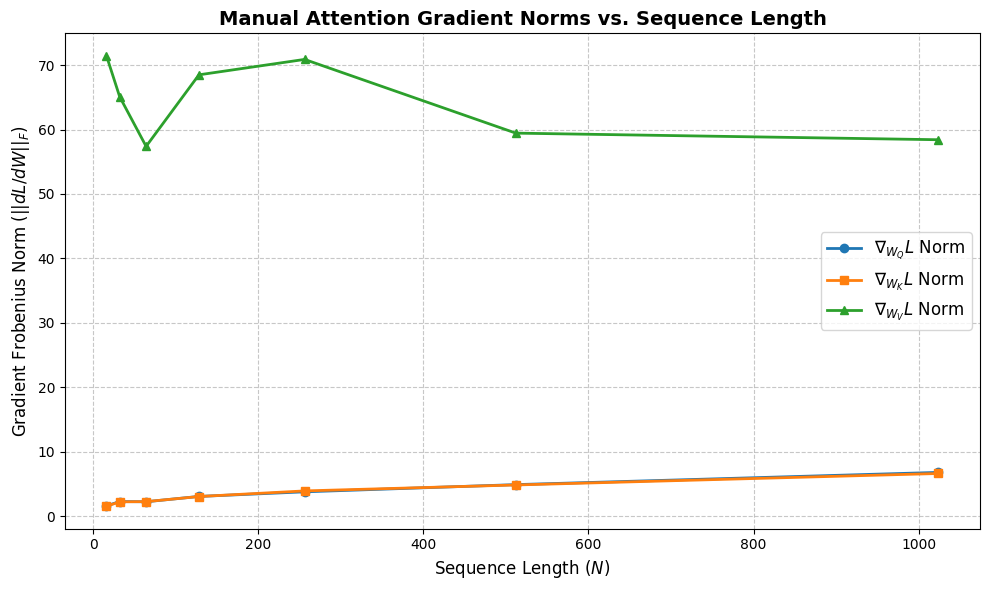

In [3]:
class ManualAttentionGradientEngine:
    """
    Custom Self-Attention Engine with a manually derived Backward Pass.
    Autograd is explicitly bypassed using raw tensor matrix operations.
    """
    def __init__(self, d_model: int, d_k: int):
        self.d_model = d_model
        self.d_k = d_k
        self.scale = 1.0 / np.sqrt(d_k)

        # Initialize weight matrices (d_model x d_k) with autograd disabled
        self.W_Q = torch.randn(d_model, d_k, requires_grad=False) * 0.02
        self.W_K = torch.randn(d_model, d_k, requires_grad=False) * 0.02
        self.W_V = torch.randn(d_model, d_k, requires_grad=False) * 0.02

    def forward(self, X: torch.Tensor):
        """
        Executes the Forward Pass and stores intermediate activations needed for Backprop.
        X shape: (N, d_model) where N = sequence length.
        """
        # Linear Projections: Q, K, V are shape (N, d_k)
        Q = X @ self.W_Q
        K = X @ self.W_K
        V = X @ self.W_V

        # Attention Scores (S) = (Q @ K^T) / sqrt(d_k) -> shape: (N, N)
        S = (Q @ K.T) * self.scale

        # Softmax Normalization across rows -> shape: (N, N)
        A = torch.softmax(S, dim=-1)

        # Context Output (O) = A @ V -> shape: (N, d_k)
        O = A @ V

        # Cache activations for backpropagation calculus
        self.cache = {'X': X, 'Q': Q, 'K': K, 'V': V, 'S': S, 'A': A, 'O': O}
        return O

    def backward(self, dL_dO: torch.Tensor):
        """
        Executes Manual Backward Pass calculus for Loss L w.r.t W_Q, W_K, and W_V.
        dL_dO shape: (N, d_k) - Gradient of Loss with respect to Context Output.
        """
        X = self.cache['X']
        Q = self.cache['Q']
        K = self.cache['K']
        V = self.cache['V']
        A = self.cache['A']

        # 1. Gradient w.r.t Value Weights (W_V)
        # O = A @ V  ==>  dL/dV = A^T @ dL/dO
        dL_dV = A.T @ dL_dO                                 # shape: (N, d_k)
        # V = X @ W_V  ==>  dL/dW_V = X^T @ dL/dV
        dL_dW_V = X.T @ dL_dV                               # shape: (d_model, d_k)

        # 2. Gradient w.r.t Attention Probabilities (A)
        # O = A @ V  ==>  dL/dA = dL/dO @ V^T
        dL_dA = dL_dO @ V.T                                 # shape: (N, N)

        # 3. Softmax Derivative: dL/dS = A * (dL/dA - sum(dL/dA * A, axis=-1))
        # Vectorized row-wise Softmax Jacobian multiplication
        sum_dL_dA_A = torch.sum(dL_dA * A, dim=-1, keepdim=True)
        dL_dS = A * (dL_dA - sum_dL_dA_A)                   # shape: (N, N)

        # Apply Scaling Factor from scaled dot-product attention
        dL_dS = dL_dS * self.scale                          # shape: (N, N)

        # 4. Gradient w.r.t Queries (Q) and Query Weights (W_Q)
        # S = (Q @ K^T) * scale  ==>  dL/dQ = dL/dS @ K
        dL_dQ = dL_dS @ K                                   # shape: (N, d_k)
        # Q = X @ W_Q  ==>  dL/dW_Q = X^T @ dL/dQ
        dL_dW_Q = X.T @ dL_dQ                               # shape: (d_model, d_k)

        # 5. Gradient w.r.t Keys (K) and Key Weights (W_K)
        # S = (Q @ K^T) * scale  ==>  dL/dK = (dL/dS)^T @ Q
        dL_dK = dL_dS.T @ Q                                 # shape: (N, d_k)
        # K = X @ W_K  ==>  dL/dW_K = X^T @ dL/dK
        dL_dW_K = X.T @ dL_dK                               # shape: (d_model, d_k)

        return dL_dW_Q, dL_dW_K, dL_dW_V


def track_gradients_over_sequence_lengths(seq_lengths, d_model=64, d_k=64):
    """
    Simulates forward and manual backward passes across varying sequence lengths
    and tracks L2 norm magnitudes for dW_Q, dW_K, and dW_V.
    """
    engine = ManualAttentionGradientEngine(d_model=d_model, d_k=d_k)

    norm_W_Q, norm_W_K, norm_W_V = [], [], []

    for seq_len in seq_lengths:
        # Generate dummy input sequence and downstream gradient dL/dO
        X = torch.randn(seq_len, d_model, requires_grad=False)
        dL_dO = torch.randn(seq_len, d_k, requires_grad=False)

        # Run Forward Pass
        _ = engine.forward(X)

        # Run Manual Backward Pass
        dW_Q, dW_K, dW_V = engine.backward(dL_dO)

        # Compute and record Frobenius / L2 gradient norms
        norm_W_Q.append(torch.norm(dW_Q).item())
        norm_W_K.append(torch.norm(dW_K).item())
        norm_W_V.append(torch.norm(dW_V).item())

    return norm_W_Q, norm_W_K, norm_W_V


def plot_gradient_flow(seq_lengths, norm_W_Q, norm_W_K, norm_W_V):
    """
    Graphs gradient magnitude behavior across different sequence lengths.
    """
    plt.figure(figsize=(10, 6))
    plt.plot(seq_lengths, norm_W_Q, marker='o', linewidth=2, label=r'$\nabla_{W_Q} L$ Norm')
    plt.plot(seq_lengths, norm_W_K, marker='s', linewidth=2, label=r'$\nabla_{W_K} L$ Norm')
    plt.plot(seq_lengths, norm_W_V, marker='^', linewidth=2, label=r'$\nabla_{W_V} L$ Norm')

    plt.title("Manual Attention Gradient Norms vs. Sequence Length", fontsize=14, fontweight='bold')
    plt.xlabel("Sequence Length ($N$)", fontsize=12)
    plt.ylabel("Gradient Frobenius Norm ($||dL/dW||_F$)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    # Test sequence lengths from 16 to 1024 tokens
    sequence_lengths = [16, 32, 64, 128, 256, 512, 1024]

    print("1. Executing manual backprop across varying sequence lengths...")
    grad_Q, grad_K, grad_V = track_gradients_over_sequence_lengths(sequence_lengths)

    print("\n2. Summary of Manual Gradient Norms:")
    print(f"{'Seq Len (N)':<12} | {'||dW_Q||':<12} | {'||dW_K||':<12} | {'||dW_V||':<12}")
    print("-" * 52)
    for idx, N in enumerate(sequence_lengths):
        print(f"{N:<12} | {grad_Q[idx]:<12.4f} | {grad_K[idx]:<12.4f} | {grad_V[idx]:<12.4f}")

    print("\n3. Plotting gradient trajectory graph...")
    plot_gradient_flow(sequence_lengths, grad_Q, grad_K, grad_V)